# Intro

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [4]:
# dataset is generated and in y some random noise is added 
X = 6*np.random.rand(200,1)-3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200,1)

# y = 0.8x^2 + 0.9x + 2

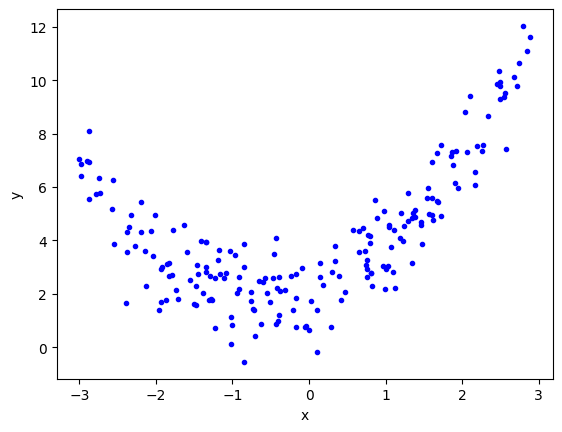

In [5]:
plt.plot(X,y, 'b.')
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [6]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

In [7]:
# Applying linear regression
lr = LinearRegression()

In [8]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
y_pred = lr.predict(X_test)
r2_score(y_test, y_pred)

0.2662449285478141

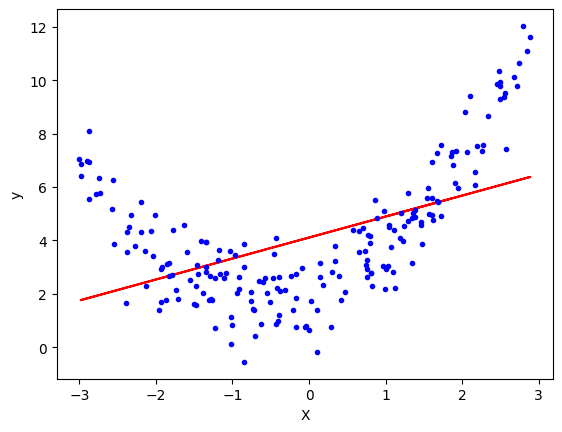

In [10]:
plt.plot(X_train, lr.predict(X_train), color='r')
plt.plot(X,y, 'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [11]:
#Now applying polynomial Linear regression
# need to apply transform to both xtrain and xtest and dont apply transform to the output y 
poly = PolynomialFeatures(degree=2)
X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [12]:
print(X_train[0])
print(X_train_trans[0])

[1.84894312]
[1.         1.84894312 3.41859065]


In [13]:
# now again we will train our model 
lr = LinearRegression()
lr.fit(X_train_trans, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
y_pred = lr.predict(X_test_trans)

In [15]:
r2_score(y_test, y_pred)

0.820394525229354

In [16]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.87006011 0.81888907]]
[2.04375766]


In [17]:
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)


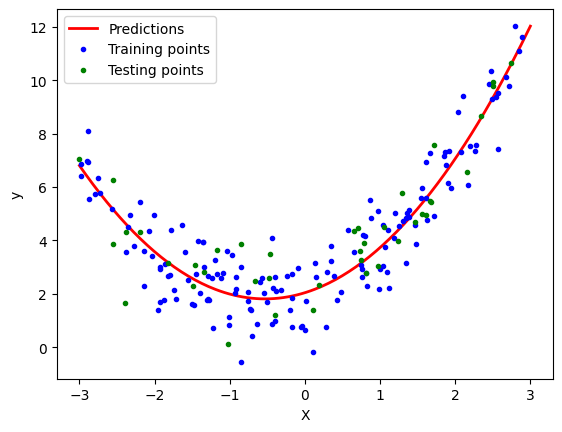

In [19]:
plt.plot(X_new, y_new, 'r-', linewidth=2, label = "Predictions")
plt.plot(X_train, y_train, 'b.', label = "Training points")
plt.plot(X_test, y_test, 'g.', label="Testing points")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()